### Loading training data

In [1]:
%%time
import os
import json
import sys
from pathlib import Path

import numpy as np

if Path.cwd().name == "plotting":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

from eval.paths import DATA_ROOT

SAVE_DIR = DATA_ROOT
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")
failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
wait_sv = targets["wait_sv"]
qs = targets["qs"]

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)

XMATCH_COLS = meta["XMATCH_COLS"]
XSUB_COLS = meta["XSUB_COLS"]
cards = meta["cards"]
NCAT_MATCH = meta["NCAT_MATCH"]
NCAT_SUB = meta["NCAT_SUB"]
n_base = meta["n_base"]

X = Xmatch[:, :n_base]

# The experiment split, as eval/splits.py builds it (design 8020) and
# experiment-setup.ipynb saved it. (targets' tr_mask/te_mask are only before/after
# 2025-07-01 -- not this split.)
SPLIT = np.load(os.path.join(SAVE_DIR, "splits_8020.npz"))
with open(os.path.join(SAVE_DIR, "splits_meta.json")) as f:
    SPLIT_META = json.load(f)

print(f"working directory: {os.getcwd()}")
print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape} | split {SPLIT_META['design']}, "
      f"cutoff {SPLIT_META['cutoff_utc']}, validation date V {SPLIT_META['val_start_utc']}")

working directory: /home/amaustin/Research/fife-batch-jobs/scripts
Loaded Xmatch (64088358, 42) and Xsub (64088358, 26) | split 8020, cutoff 2025-07-10 00:00, validation date V 2025-06-24 00:00
CPU times: user 6.87 s, sys: 364 ms, total: 7.23 s
Wall time: 4.25 s


#### Features

In [14]:
print(f"Xmatch {Xmatch.shape} -- match-time tasks (Failed, hw_fault, 3-class fault):")
for i, nme in enumerate(XMATCH_COLS):
    print(f"  [{i:2d}] {nme}")
print(f"\nXsub {Xsub.shape} -- submission-time task (wait_time):")
for i, nme in enumerate(XSUB_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: trail1h_* (leak-free trailing rates, 1h window, self-excluded),")
print("  log_idle_queue_depth (submitted-not-started at submit), log_camp_trail_wait,")
print("  log_*_running (leak-free concurrent-running counts, self-excluded)")
print("targets: Failed (binary) | hw_fault (binary; matched & typed rows) | "
      "fault_type (3-class) | wait_log = log1p(wait s)")

Xmatch (64088358, 42) -- match-time tasks (Failed, hw_fault, 3-class fault):
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignType
  [ 6] TestLaunch
  [ 7] JobsubGroup
  [ 8] Image
  [ 9] BlacklistSites
  [10] MatchSite
  [11] MatchEntry
  [12] MatchQueue
  [13] MatchResource
  [14] MatchCpus
  [15] RequestCpus (std)
  [16] RequestDisk (std)
  [17] RequestMemory (std)
  [18] RequestSlots (std)
  [19] ExecutableSize (std)
  [20] TransferInputMB (std)
  [21] ExpectedLifetime (std)
  [22] TotalSubmitProcs (std)
  [23] CpusProvisioned (std)
  [24] DiskProvisioned (std)
  [25] MemoryProvisioned (std)
  [26] sin_hour@match
  [27] cos_hour@match
  [28] sin_wday@match
  [29] cos_wday@match
  [30] trail1m_site_fail
  [31] trail60m_site_fail
  [32] trail1m_site_hw
  [33] trail60m_site_hw
  [34] trail1m_camp_fail
  [35] trail60m_camp_fail
  [36] trail60m_node_fail
  [37] trail1440m_node_fail
  [38] trail60m_node_hw
  [39] trail1440m_node_hw

#### Experiment population
Every job that ran and is not a pilot, from the 8020 split; each arm's fit / validation / test sets and their failure rate.

In [3]:
# E1 predicts failure for every job that ran and is not a pilot (the harness target
# mask, already applied in splits_8020.npz). Each arm's fit / validation / test sets,
# with the failure rate each metric's baseline depends on.
import pandas as pd

yv = np.asarray(failed)
E1_SETS = {
    "random": {"fit": SPLIT["e1e3__random__fit"], "val": SPLIT["e1e3__random__val"],
               "test": SPLIT["e1e3__random_test"], "oot": SPLIT["e1e3__oot_test"]},
    "temporal": {"fit": SPLIT["e1e3__temporal__fit"], "val": SPLIT["e1e3__temporal__val"],
                 "test": SPLIT["e1e3__oot_test"], "oot": SPLIT["e1e3__oot_test"]},
}
rows = [{"arm": arm, "set": name, "jobs": len(i), "failure rate": yv[i].mean()}
        for arm, sets in E1_SETS.items() for name, i in sets.items()]
display(pd.DataFrame(rows).style.format({"jobs": "{:,}", "failure rate": "{:.2%}"}))
print("The temporal arm's test set is the out-of-time set, so its 'test' and 'oot' rows match.")

,arm,set,jobs,failure rate
0,random,fit,"36,379,869",14.60%
1,random,val,"3,942,058",14.61%
2,random,test,"4,481,188",14.56%
3,random,oot,"11,239,921",13.30%
4,temporal,fit,"36,379,869",14.22%
5,temporal,val,"3,942,058",18.12%
6,temporal,test,"11,239,921",13.30%
7,temporal,oot,"11,239,921",13.30%


The temporal arm's test set is the out-of-time set, so its 'test' and 'oot' rows match.


### Loading failure prediction models and feature importances

In [14]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances
from eval.paths import model_dir

# Permutation importance (neural models) and attention mass (TabNet) are measured on a
# random 200,000-job sample of the out-of-time test set -- jobs neither arm trained on.
# Tree importances come from the saved models themselves (split gain). The same sample
# is used for both arms' models.
_oot = E1_SETS["temporal"]["oot"]
_rng = np.random.default_rng(0)
eval_idx = np.sort(_rng.choice(_oot, size=min(200_000, len(_oot)), replace=False))
X_eval = np.ascontiguousarray(Xmatch[eval_idx], dtype=np.float32)
y_eval = np.ascontiguousarray(yv[eval_idx])
print(f"importance sample: {len(eval_idx):,} OOT jobs, {y_eval.mean():.2%} failed")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _models = ["xgboost", "lightgbm", "catboost", "mlp", "tabnet", "saint", "ft", "tsmixer"]
    E1_IMP = load_saved_importances(
        models=_models,
        model_dirs=[model_dir("e1", m, create=False) for m in _models],
        exp_tag=None,
        splits=["random", "temporal"],
        n_feats=len(XMATCH_COLS),
        X_eval=X_eval,
        y_eval=y_eval,
    )

importance sample: 200,000 OOT jobs, 13.24% failed
[Loaded Tree Model] xgboost    (random  ) <- /mnt/scratch/ssd/amaustin/models/e1/xgboost/xgboost_bin_random.json
[Loaded Tree Model] xgboost    (temporal) <- /mnt/scratch/ssd/amaustin/models/e1/xgboost/xgboost_bin_temporal.json
[Loaded Tree Model] lightgbm   (random  ) <- /mnt/scratch/ssd/amaustin/models/e1/lightgbm/lightgbm_bin_random.txt
[Loaded Tree Model] lightgbm   (temporal) <- /mnt/scratch/ssd/amaustin/models/e1/lightgbm/lightgbm_bin_temporal.txt
[Loaded Tree Model] catboost   (random  ) <- /mnt/scratch/ssd/amaustin/models/e1/catboost/catboost_bin_random.txt
[Loaded Tree Model] catboost   (temporal) <- /mnt/scratch/ssd/amaustin/models/e1/catboost/catboost_bin_temporal.txt
[Computed Permutation Imp] mlp        (random  ) on cuda
[Computed Permutation Imp] mlp        (temporal) on cuda
[Loaded TabNet Model] tabnet     (random  ) computed feature importances successfully.
[Loaded TabNet Model] tabnet     (temporal) computed feature

## Feature Importance
### Random split

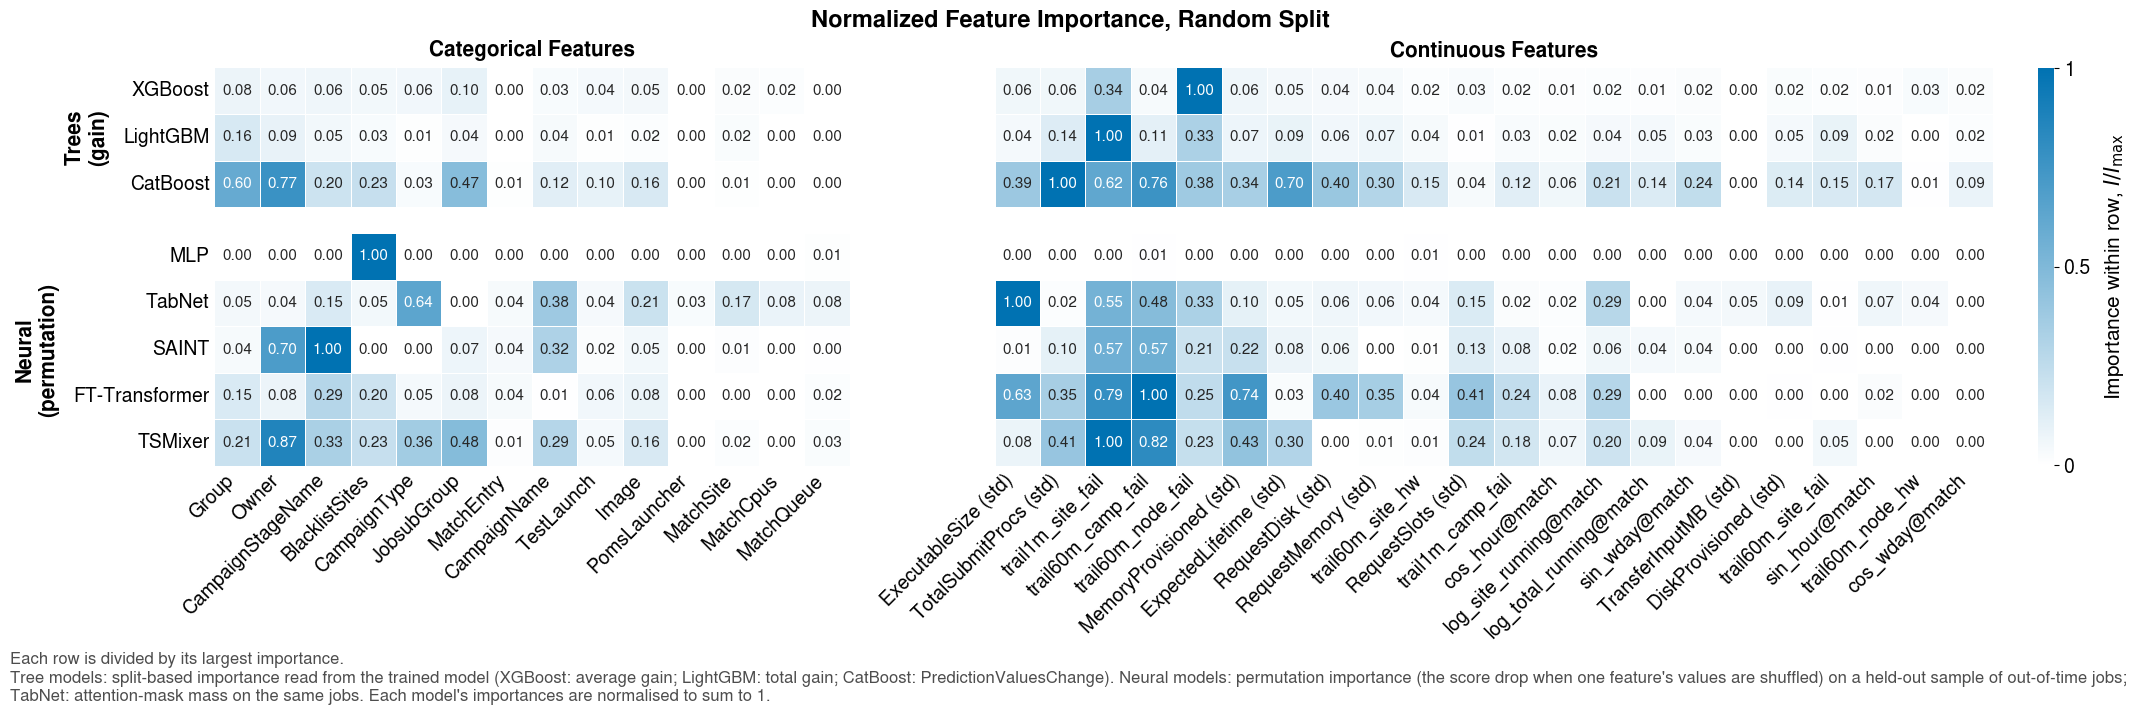

In [15]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    split_key="random",
    exp="e1", 
    output_prefix="feature_split_imp_heatmap",
)

### Temporal split

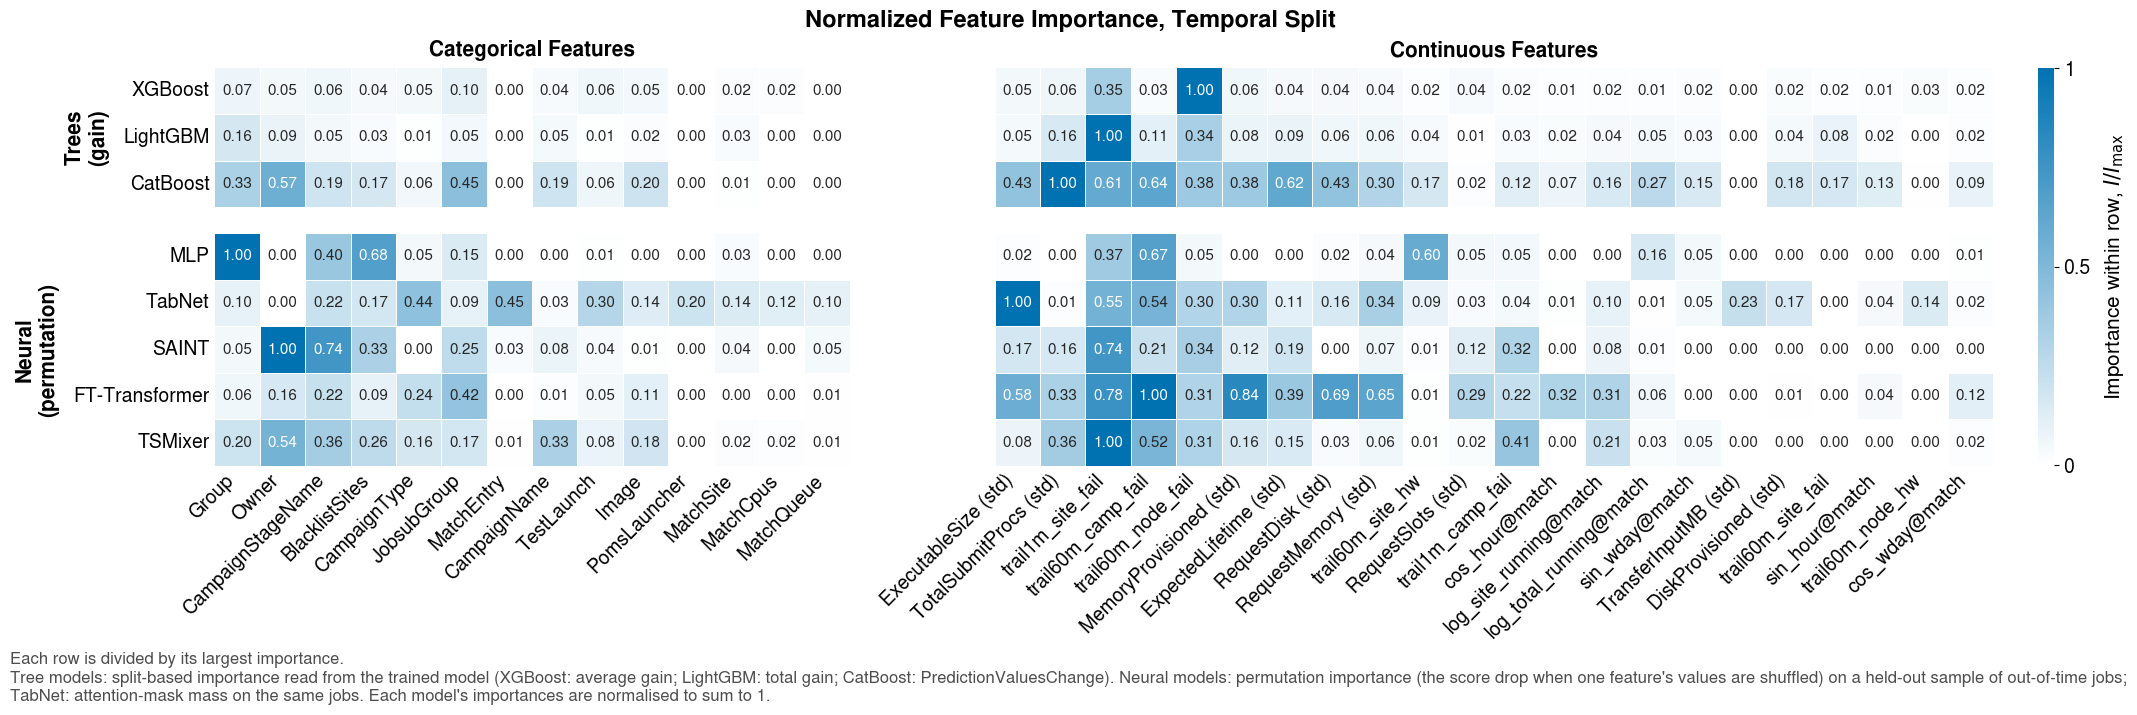

In [16]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    split_key="temporal",
    exp="e1",
    output_prefix="feature_split_imp_heatmap",
)

### Feature gain shift (random -> temporal)

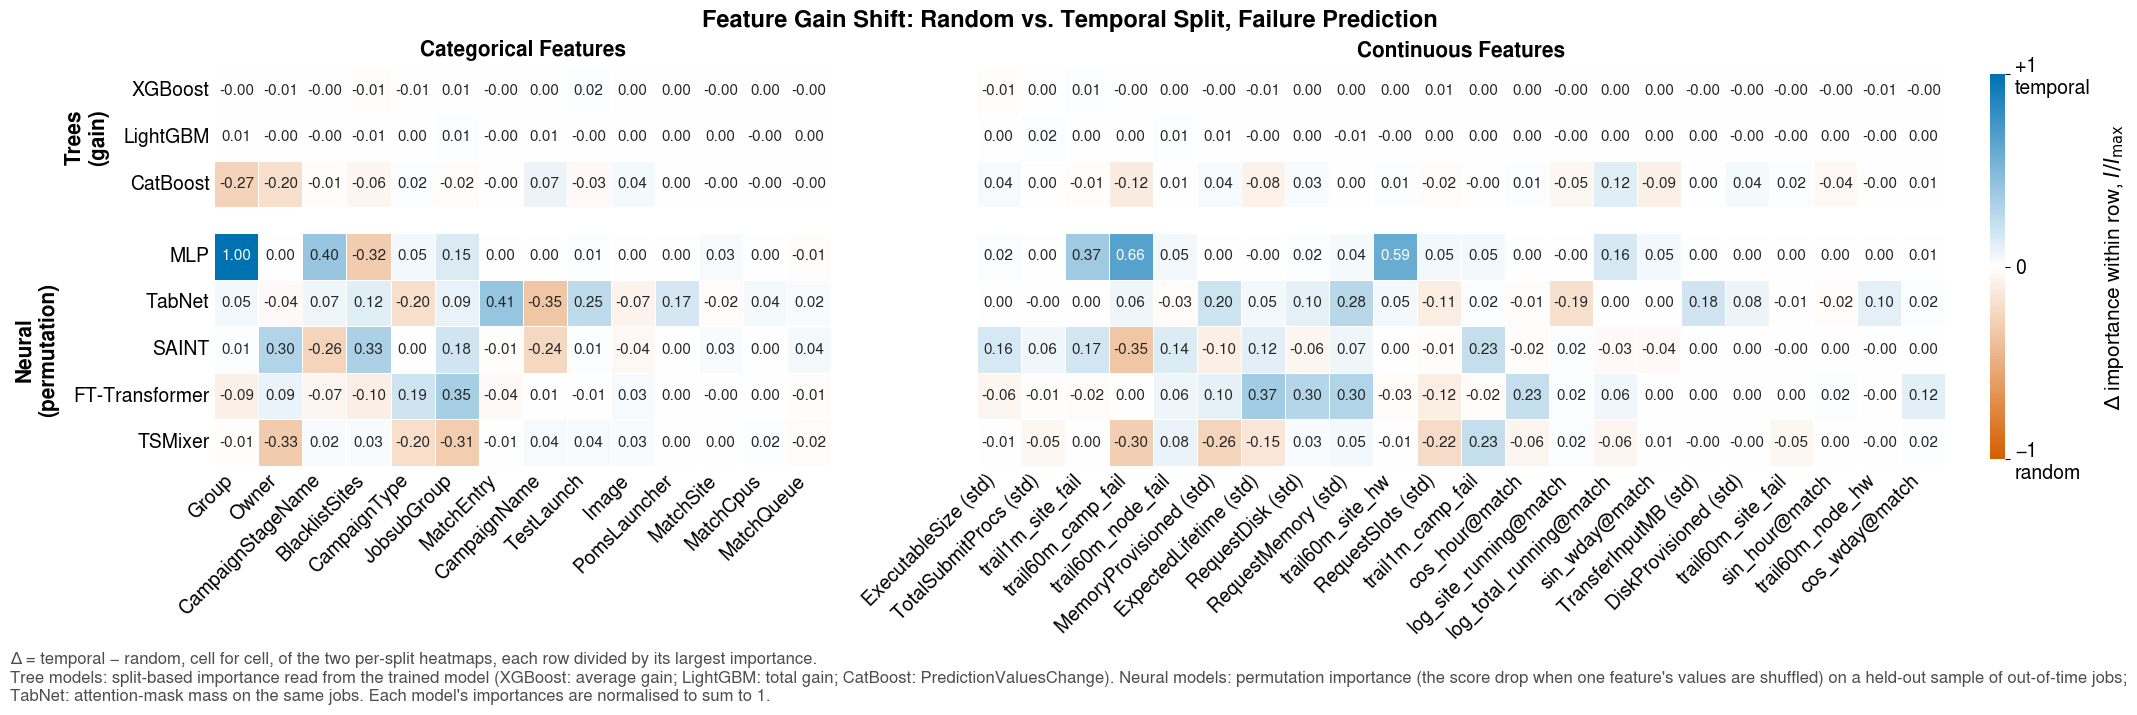

,Group,Owner,CampaignStageName,BlacklistSites,CampaignType,JobsubGroup,MatchEntry,CampaignName,TestLaunch,Image,...,cos_hour@match,log_site_running@match,log_total_running@match,sin_wday@match,TransferInputMB (std),DiskProvisioned (std),trail60m_site_fail,sin_hour@match,trail60m_node_hw,cos_wday@match
XGBoost,-0.004500,-0.005176,-0.002533,-0.013150,-0.006047,0.005089,-0.000302,0.004299,0.015220,0.003131,...,0.000031,-0.000605,0.000454,0.001693,-0.000112,-0.000407,-0.002613,-0.000048,-0.006730,-0.001969
LightGBM,0.007724,-0.003214,-0.004358,-0.005454,0.000011,0.011717,-0.000071,0.007692,-0.000992,0.001353,...,0.000672,-0.000048,0.000951,0.001833,0.000024,-0.002215,-0.004170,0.002413,-0.000371,0.001173
CatBoost,-0.271899,-0.197328,-0.010386,-0.058885,0.022798,-0.018773,-0.004583,0.073818,-0.033989,0.041020,...,0.013257,-0.053780,0.121787,-0.090231,0.000000,0.040295,0.015843,-0.041953,-0.000747,0.006205
MLP,1.000000,0.000000,0.400705,-0.317522,0.047373,0.145799,0.000360,0.000000,0.011479,0.000000,...,0.000000,-0.000847,0.157598,0.049001,0.000000,0.000000,0.000000,0.000000,0.002919,0.007682
TabNet,0.047160,-0.036059,0.065785,0.123009,-0.196237,0.092891,0.411547,-0.352675,0.254004,-0.074845,...,-0.009755,-0.189595,0.002696,0.001779,0.181331,0.075424,-0.006952,-0.024275,0.102170,0.017909
SAINT,0.013920,0.299527,-0.259982,0.326666,0.002592,0.180807,-0.008042,-0.238657,0.012566,-0.043491,...,-0.018550,0.017353,-0.031474,-0.036336,0.000091,0.000278,-0.004744,0.000000,-0.000909,0.000000
FT-Transformer,-0.089394,0.085678,-0.069810,-0.103757,0.189211,0.346380,-0.037452,0.006991,-0.007726,0.031417,...,0.232716,0.022159,0.056422,0.000000,0.000324,0.001845,0.000000,0.016648,-0.000927,0.115143
TSMixer,-0.010617,-0.327441,0.024325,0.030015,-0.200126,-0.305479,-0.005857,0.036578,0.038811,0.028243,...,-0.064811,0.017209,-0.060528,0.007222,-0.000366,-0.003705,-0.051480,0.000000,-0.002009,0.015247


In [17]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

# One table, each row scaled by its own max |delta|. Trees and neural models sit in
# separate row blocks: split gain and permutation importance are different quantities,
# so the per-row scaling does not put them on a common footing (see the figure note).
imp_diff_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,
    exp = "e1",
    title="Feature Gain Shift: Random vs. Temporal Split, Failure Prediction",
    output_prefix="imp_diff_heatmap",
)


## Performance evaluation
Seed-averaged results from the harness (`results/protocol_eval/<model>.json`).

In [8]:
# The harness saves every E1 run's results -- each arm's own test set and the shared
# out-of-time set -- in results/protocol_eval/<model>.json, with predictions on disk,
# so nothing is re-evaluated here. Mean +/- SD over the seeded runs.
import json
import pandas as pd
from eval.helper import aggregate_seeds

from eval.helper import load_results
E1_RESULTS = load_results("protocol_eval")

MODEL_NAMES = {"xgboost": "XGBoost", "lightgbm": "LightGBM", "catboost": "CatBoost",
               "mlp": "MLP", "tabnet": "TabNet", "saint": "SAINT",
               "ft": "FT-Transformer", "tsmixer": "TSMixer"}
COLS = ["roc_auc", "pr_auc", "precision", "recall", "f1"]
rows = []
for mk, name in MODEL_NAMES.items():
    if mk not in E1_RESULTS:
        continue
    for arm, block, label in (("random", "", "Random, Random"), ("random", "oot.", "Random, OOT"),
                              ("temporal", "oot.", "Temporal, OOT")):
        runs = [v for k, v in E1_RESULTS[mk].items() if k.startswith(f"{arm}__seed")]
        if not runs:
            continue
        agg = aggregate_seeds(runs)
        rec = {"model": name, "arm": label, "seeds": len(runs)}
        for c in COLS:
            b = agg.get(block + c)
            rec[c] = f"{b['mean']:.3f} ± {b['std']:.3f}" if b else ""
        rows.append(rec)
summary = pd.DataFrame(rows)
display(summary) if len(summary) else print("no seeded E1 results yet")

,model,arm,seeds,roc_auc,pr_auc,precision,recall,f1
0,XGBoost,"Random, Random",3,0.985 ± 0.000,0.936 ± 0.001,0.862 ± 0.006,0.836 ± 0.007,0.849 ± 0.001
1,XGBoost,"Random, OOT",3,0.875 ± 0.001,0.626 ± 0.009,0.720 ± 0.024,0.396 ± 0.042,0.510 ± 0.032
2,XGBoost,"Temporal, OOT",3,0.870 ± 0.004,0.597 ± 0.010,0.433 ± 0.034,0.737 ± 0.034,0.544 ± 0.018
3,LightGBM,"Random, Random",3,0.937 ± 0.000,0.686 ± 0.001,0.723 ± 0.001,0.936 ± 0.000,0.816 ± 0.001
4,LightGBM,"Random, OOT",3,0.795 ± 0.010,0.395 ± 0.016,0.511 ± 0.015,0.691 ± 0.017,0.588 ± 0.016
5,LightGBM,"Temporal, OOT",3,0.779 ± 0.008,0.377 ± 0.011,0.505 ± 0.010,0.656 ± 0.018,0.571 ± 0.011
6,CatBoost,"Random, Random",3,0.914 ± 0.000,0.618 ± 0.002,0.668 ± 0.002,0.904 ± 0.001,0.768 ± 0.002
7,CatBoost,"Random, OOT",3,0.825 ± 0.005,0.420 ± 0.013,0.510 ± 0.018,0.762 ± 0.011,0.611 ± 0.012
8,CatBoost,"Temporal, OOT",3,0.830 ± 0.002,0.433 ± 0.002,0.525 ± 0.004,0.765 ± 0.006,0.623 ± 0.002
9,MLP,"Random, Random",3,0.987 ± 0.000,0.946 ± 0.000,0.880 ± 0.006,0.855 ± 0.005,0.867 ± 0.000


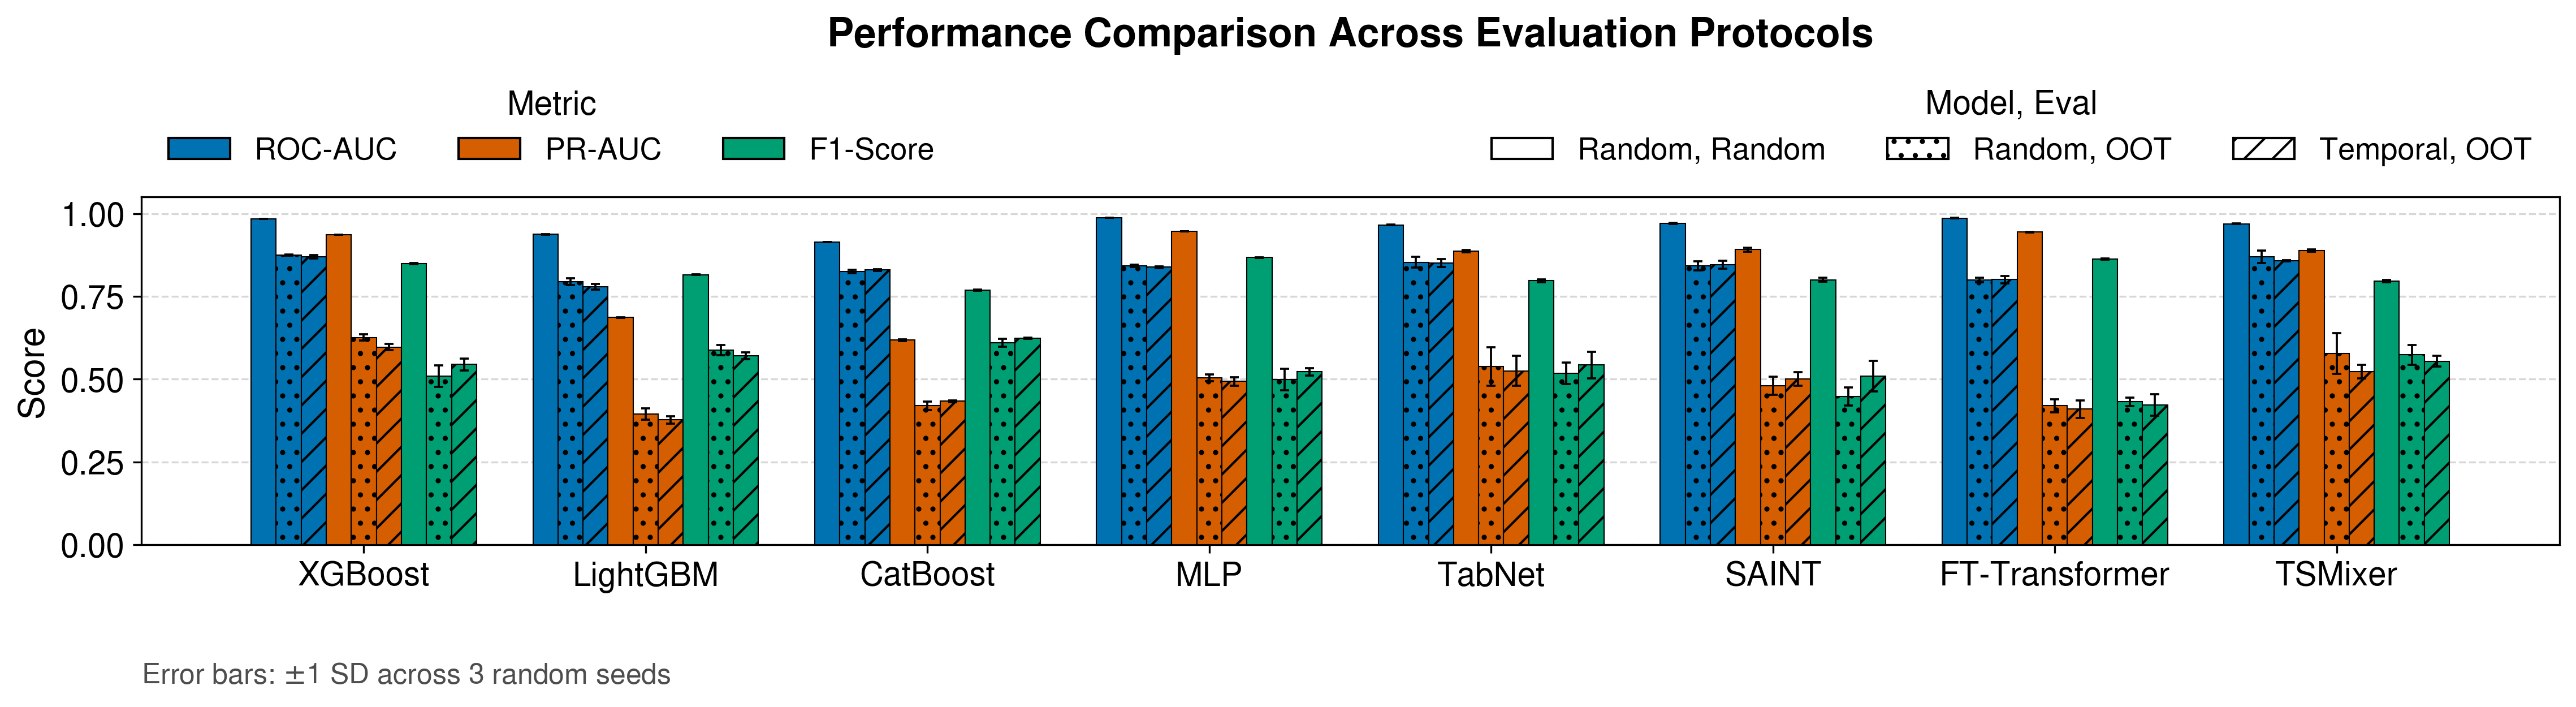

Saved plots to:
  - /home/amaustin/Research/fife-batch-jobs/scripts/output/protocol_ablation_summary.pdf
Seeds aggregated per bar: [3]
  XGBoost         temporal PR-AUC 0.5971 +/- 0.0095  (n=3)
  LightGBM        temporal PR-AUC 0.3771 +/- 0.0112  (n=3)
  CatBoost        temporal PR-AUC 0.4331 +/- 0.0019  (n=3)
  MLP             temporal PR-AUC 0.4934 +/- 0.0131  (n=3)
  TabNet          temporal PR-AUC 0.5251 +/- 0.0446  (n=3)
  SAINT           temporal PR-AUC 0.5010 +/- 0.0205  (n=3)
  FT-Transformer  temporal PR-AUC 0.4094 +/- 0.0260  (n=3)
  TSMixer         temporal PR-AUC 0.5235 +/- 0.0206  (n=3)


In [ ]:
METRICS = [
    ("roc_auc", "ROC-AUC"),
    ("pr_auc",  "PR-AUC"),
    ("f1",      "F1-Score"),
]
# (training split, label, hatch, metric prefix) -- each bar is a (model, test set).
# Both out-of-time arms read the shared OOT block ("oot."): the post-cutoff jobs neither
# arm trained on, so the two are scored on identical rows.
PROTOCOLS = [
    ("random",   "Random, Random",   "",   ""),
    ("random",   "Random, OOT",   "..", "oot."),
    ("temporal", "Temporal, OOT", "//", "oot."),
]
# Which seed each bar shows. "mean" averages every seed and draws +/-1 SD; "best"
# picks the single seed that scored highest on PRIMARY and draws ALL of that seed's
# metrics, so the bars describe one model that actually existed rather than a
# per-metric maximum stitched from different runs. Best-seed bars carry no error bar,
# because there is no spread in a single run.
SEED_PICK = "mean"          # "mean" | "best"
PRIMARY = "pr_auc"
# ----------------------------------------------------------------------------------

import json
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from eval.helper import aggregate_seeds
from eval.style import SERIES

notebook_dir = os.getcwd()
from eval.helper import load_results

MODEL_ORDER = {"xgboost":"XGBoost","lightgbm":"LightGBM","catboost":"CatBoost","mlp":"MLP",
               "tabnet":"TabNet","saint":"SAINT","ft":"FT-Transformer","tsmixer":"TSMixer"}

results = load_results("protocol_eval")   # results/protocol_eval/<model>.json
model_keys = [k for k in MODEL_ORDER if k in results]
models = [MODEL_ORDER[k] for k in model_keys]

def _flat_run(d, prefix=""):
    """Flatten nested metric blocks to dotted keys ("oot.hardware.pr_auc")."""
    out = {}
    for k, v in d.items():
        if isinstance(v, dict):
            out.update(_flat_run(v, f"{prefix}{k}."))
        elif isinstance(v, (int, float)) and not isinstance(v, bool):
            out[f"{prefix}{k}"] = float(v)
    return out


def stat(mkey, split, metric):
    """value, spread, n for this model/split. Spread is the SD across seeds in "mean"
    mode and 0 in "best" mode, where a single run is plotted."""
    # Seeded runs only: the plain `<split>` key is an older single run from before the
    # shared OOT slice, scored on a different test set.
    runs = [v for k, v in results[mkey].items() if k.startswith(f"{split}__seed")]
    if not runs:
        return np.nan, 0.0, 0
    if SEED_PICK == "best":
        flat = [_flat_run(r) for r in runs]
        scored = [f for f in flat if PRIMARY in f]
        pick = max(scored, key=lambda f: f[PRIMARY]) if scored else flat[0]
        return pick.get(metric, np.nan), 0.0, len(runs)
    b = aggregate_seeds(runs).get(metric)
    return (b["mean"], b["std"], b["n"]) if b else (np.nan, 0.0, 0)

# One base size drives every text element, so nothing drifts when the figure resizes.
FONT = 14
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Nimbus Sans",
    "font.size": FONT,
    "axes.labelsize": FONT + 1,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT - 1,
    "legend.title_fontsize": FONT,
})

n_bars = len(METRICS) * len(PROTOCOLS)
# 0.8 of the slot, shared out; at 6 bars this reproduces the previous 0.13.
w = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(max(13, 1.7 * n_bars), 5), dpi=300)
x = np.arange(len(models))
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w

seed_counts = set()
i = 0
for _mi, (mkey, mlabel) in enumerate(METRICS):
    color = SERIES[_mi % len(SERIES)]
    for pkey, plabel, hatch, mpref in PROTOCOLS:
        vals, errs = [], []
        for k in model_keys:
            mu, sd, n = stat(k, pkey, mpref + mkey)
            vals.append(mu); errs.append(sd); seed_counts.add(n)
        ax.bar(x + offsets[i], vals, w, color=color, edgecolor="black", linewidth=0.5,
               hatch=hatch,
               # Error bars are +/-1 SD across seeds; absent when a single seed was run.
               yerr=errs if any(e > 0 for e in errs) else None,
               error_kw=dict(ecolor="black", elinewidth=0.9, capsize=2, capthick=0.9),
               zorder=3)
        i += 1

ax.set_ylabel("Score")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ns = sorted(n for n in seed_counts if n)
ax.set_title("Performance Comparison Across Evaluation Protocols",
             pad=64, fontweight="bold")
# Seed provenance belongs on the figure, but under the axes so it cannot collide
# with the legends stacked above the title.
if ns and max(ns) > 1:
    rng_txt = f"{min(ns)}" + (f"-{max(ns)}" if min(ns) != max(ns) else "")
    note = (f"Bars show the single best seed of {rng_txt} by {PRIMARY}; all metrics "
            f"come from that one run, so there is no spread to draw."
            if SEED_PICK == "best" else
            f"Error bars: $\\pm$1 SD across 3 random seeds")
else:
    note = "Single seed per configuration; no variance estimate available."
ax.annotate(note, xy=(0, -0.34), xycoords="axes fraction", fontsize=FONT - 2,
            ha="left", va="top", color="0.30")

leg1 = ax.legend(handles=[Patch(facecolor=SERIES[i % len(SERIES)], edgecolor="black",
                                label=l) for i, (_, l) in enumerate(METRICS)],
                 title="Metric", loc="lower left", bbox_to_anchor=(0.0, 1.01),
                 ncol=len(METRICS), frameon=False, alignment="center")
ax.add_artist(leg1)
ax.legend(handles=[Patch(facecolor="white", edgecolor="black", hatch=h, label=l)
                   for _, l, h, _p in PROTOCOLS],
          title="Model, Eval", loc="lower right", bbox_to_anchor=(1.0, 1.01),
          ncol=len(PROTOCOLS), frameon=False, alignment="center")

plt.tight_layout()

os.makedirs(os.path.join(notebook_dir, "output"), exist_ok=True)
pdf_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.pdf")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved plots to:\n  - {pdf_path}")
print(f"Seeds aggregated per bar: {sorted(n for n in seed_counts if n)}")
for k in model_keys:
    mu, sd, n = stat(k, "temporal", "pr_auc")
    print(f"  {MODEL_ORDER[k]:15s} temporal PR-AUC {mu:.4f} +/- {sd:.4f}  (n={n})")
